# Ejercicios Practicos

25 Febrero 2026

Naomi Neriyah Casanova Rivera

In [1]:
# https://github.com/jpachecosenard1999/Module-IV-----Unsupervised-Learning

### Primera Parte

1. Seleccionar un conjunto de datos para una tarea de regresión que sea de tu interés, disponible en alguno de los repositorios mencionados en clase.

2. Tratar los valores perdidos de la serie si tiene. 

3. Aplicar al menos una transformación (en los modelos ARIMA/SARIMA es aplicar una transformación diferente a la diferenciación).

4. Aplicar a la serie modelos ARIMA/SARIMA y ARnet a la serie de tiempo.

5. Realizar análisis de residuales

6. Comparar resultados



In [2]:
# LIBRERIAS 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
import time
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import time
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor

from statsmodels.tsa.stattools import acf
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf


warnings.filterwarnings("ignore")



In [3]:
# DATOS SELECCIONADOS 
Datos = pd.read_csv('norway_new_car_sales_by_make.csv')
#https://www.kaggle.com/datasets/dmi3kno/newcarsalesnorway

In [4]:
Datos

,Year,Month,Make,Quantity,Pct
0,2007,1,Toyota,2884,22.7
1,2007,1,Volkswagen,2521,19.9
2,2007,1,Peugeot,1029,8.1
3,2007,1,Ford,870,6.9
4,2007,1,Volvo,693,5.5
...,...,...,...,...,...
4372,2017,1,Nilsson,3,0.0
4373,2017,1,Maserati,2,0.0
4374,2017,1,Ferrari,1,0.0
4375,2017,1,Smart,1,0.0


In [5]:
Datos["Year"].unique()

array([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017],
      dtype=int64)

In [6]:
Datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4377 entries, 0 to 4376
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      4377 non-null   int64  
 1   Month     4377 non-null   int64  
 2   Make      4367 non-null   object 
 3   Quantity  4377 non-null   int64  
 4   Pct       4377 non-null   float64
dtypes: float64(1), int64(3), object(1)
memory usage: 171.1+ KB


In [7]:
missing_cols = Datos.columns[Datos.isnull().any()].tolist()
missing_cols

['Make']

In [8]:
Datos["Periodo"] = pd.to_datetime(
    dict(year=Datos["Year"], month=Datos["Month"], day=1)
).dt.to_period("M")

In [9]:
Datos.head()

,Year,Month,Make,Quantity,Pct,Periodo
0,2007,1,Toyota,2884,22.7,2007-01
1,2007,1,Volkswagen,2521,19.9,2007-01
2,2007,1,Peugeot,1029,8.1,2007-01
3,2007,1,Ford,870,6.9,2007-01
4,2007,1,Volvo,693,5.5,2007-01


In [10]:
# Patrones redundantes : duplicados exactos
if Datos.duplicated().any():
    print("Se encontraron filas redundantes (duplicados exactos). Eliminando la primera instancia de cada grupo...")
    Datos = Datos.drop_duplicates(keep='first')
else:
    print("No se encontraron Patrones Redundantes :)")

No se encontraron Patrones Redundantes :)


In [11]:
Datos.columns

Index(['Year', 'Month', 'Make', 'Quantity', 'Pct', 'Periodo'], dtype='object')

In [12]:
Datos["Year"].unique()

array([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017],
      dtype=int64)

In [13]:
# COMO LAS VENTAS ESTAN DIVIDIDAS POR MARCA , VAMOS A AGRUPAR LOS DATOS , PARA TENER LA INFO TOTAL DE LAS VENTAS 
Ventas_Totales = Datos.groupby("Periodo")["Quantity"].sum().reset_index()

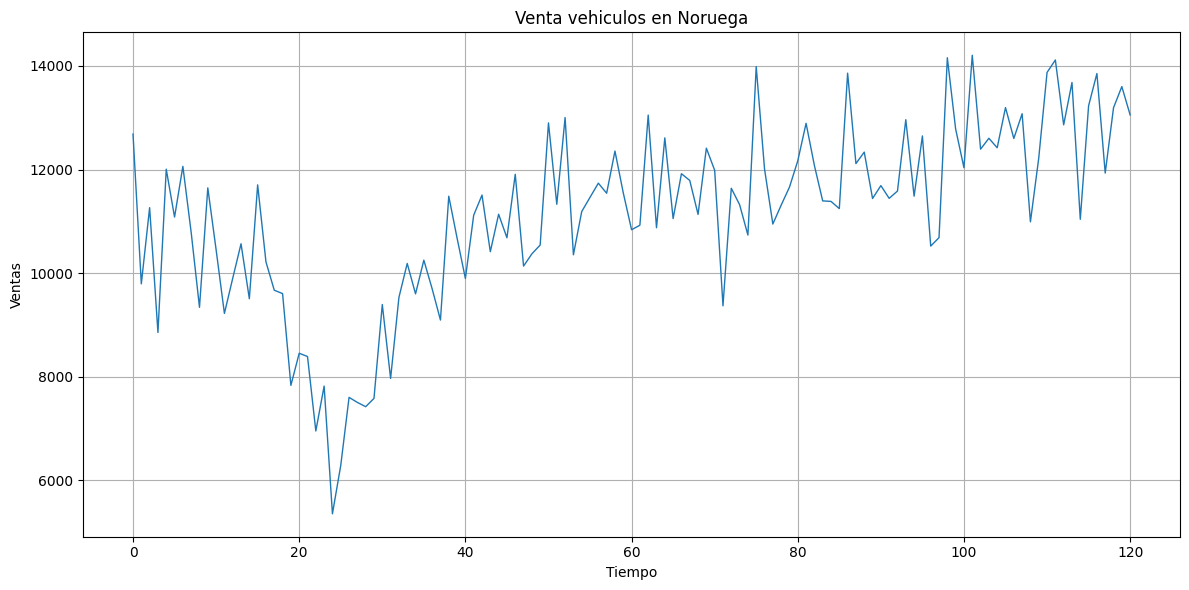

In [14]:
# VISUALIZACIÓN DE DATOS

# Creamos un índice para visualizar la serie
Ventas_Totales.index = pd.RangeIndex(start=0, stop=len(Ventas_Totales), step=1)

# Visualizar
plt.figure(figsize=(12,6))
plt.plot(Ventas_Totales["Quantity"], linewidth=1)
plt.title("Venta vehiculos en Noruega")
plt.xlabel("Tiempo")
plt.ylabel("Ventas")
plt.grid(True)
plt.tight_layout()
plt.show()

##### Aplicando una transformación _________________________________________________________________________________________________________________________________

In [15]:
# DEFINIMOS LA SERIE

s = Ventas_Totales["Quantity"].astype(float).copy()
s.name = "car_sales"
s.index = pd.RangeIndex(start=0, stop=len(s), step=1)
    
s = s.replace([np.inf, -np.inf], np.nan).dropna()

In [16]:
# ELEGIMOS APLICAR LA NORMALIZACIÓN MIN-MAX PARA QUE LOS DATOS ESTEN EN LA MISMA ESCALA
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
s_norm = pd.Series(
    scaler.fit_transform(s.values.reshape(-1, 1)).ravel(),
    index=s.index,
    name="car_sales_norm_0_1"
)

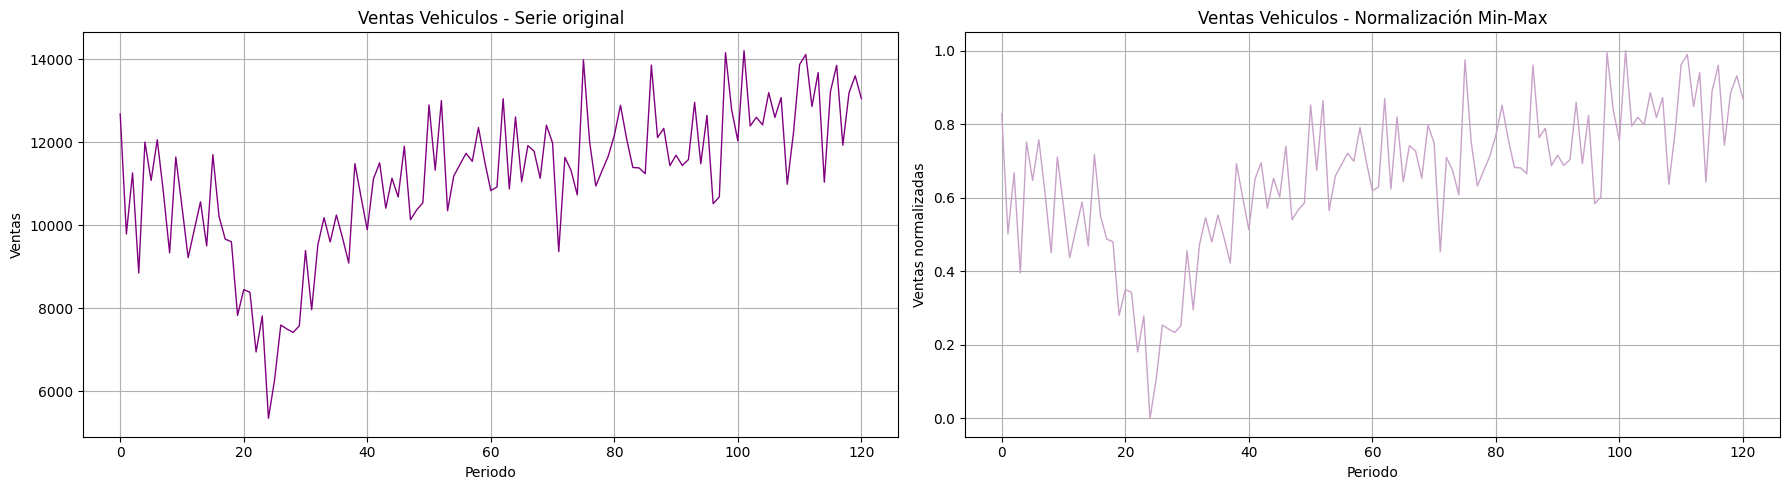

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

# SERIE ORIGINAL 
ax[0].plot(s, linewidth=1, color="purple")
ax[0].set_title("Ventas Vehiculos - Serie original")
ax[0].set_xlabel("Periodo" if not isinstance(s.index, pd.DatetimeIndex) else "Fecha")
ax[0].set_ylabel("Ventas")
ax[0].grid(True)

# SERIE APLICANDO UNA TRANSFORMACION (NORMALIZACIÓN MIN-MAX)
ax[1].plot(s_norm, linewidth=1, color="#C8A2C8")
ax[1].set_title("Ventas Vehiculos - Normalización Min-Max")
ax[1].set_xlabel("Periodo" if not isinstance(s.index, pd.DatetimeIndex) else "Fecha")
ax[1].set_ylabel("Ventas normalizadas")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [18]:
# Guardemos la info transformada
s_norm.to_csv("Car_sales_normalized.csv", index=True)

##### Dividiendo en datos de entrenamiento y de prueba __________________________________________________________________________________________________________________

In [19]:
Ventas_Totales

,Periodo,Quantity
0,2007-01,12685
1,2007-02,9793
2,2007-03,11264
3,2007-04,8854
4,2007-05,12007
...,...,...
116,2016-09,13854
117,2016-10,11932
118,2016-11,13194
119,2016-12,13602


In [20]:
# 80 % para train y 20 % para test
n_train = int(len(s_norm) * 0.8)
n_test = len(s_norm) - n_train

In [21]:
# DATOS DE ENTRENAMIENTO Y VALIDACION
SEMILLA = 2024

y_train = s_norm[:n_train]
y_test = s_norm[n_train:n_train + n_test]

##### Aplicando modelos ARIMA/SARIMA Y AriNET _______________________________________________________________________________________________________________________

In [22]:
# MODELO ARIMA

In [23]:
ORDER = (1, 1, 3)
SEASONAL_ORDER = (2, 1, 1, 24)
TREND = 'n' # 'n' (ninguno), 'c' (constante), 't' (tendencia lineal), 'ct' (constante + tendencia)

idx_train = pd.RangeIndex(1, len(y_train) + 1)
idx_test = pd.RangeIndex(len(y_train) + 1, len(y_train) + len(y_test) + 1)

print(f"✓ Datos de ejemplo generados: {len(y_train)} entrenamiento, {len(y_test)} prueba")

y_train_series = y_train #pd.Series(y_train, index=idx_train)
y_test_series = y_test#pd.Series(y_test, index=idx_test)


✓ Datos de ejemplo generados: 96 entrenamiento, 25 prueba


In [24]:

# ============================================================
# 2. FUNCIONES DE UTILIDAD
# ============================================================
def calcular_metricas(y_real, y_pred, n_params=0, dataset_name=""):
    """Calcula métricas de evaluación para series temporales"""
    y_real = np.array(y_real).flatten()
    y_pred = np.array(y_pred).flatten()

    min_len = min(len(y_real), len(y_pred))
    y_real = y_real[:min_len]
    y_pred = y_pred[:min_len]

    n = len(y_real)

    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_pred)

    smape = 100 * np.mean(2 * np.abs(y_pred - y_real) / (np.abs(y_real) + np.abs(y_pred) + 1e-10))

    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
    r2 = 1 - (ss_res / (ss_tot + 1e-10))

    aic = bic = np.nan
    if n_params > 0 and n > 0:
        aic = n * np.log(mse) + 2 * n_params
        bic = n * np.log(mse) + n_params * np.log(n)

    data_range = np.max(y_real) - np.min(y_real)
    mse_percent = 100 * mse / (data_range ** 2 + 1e-10) if data_range > 0 else 0
    rmse_percent = 100 * rmse / data_range if data_range > 0 else 0

    return {
        f'MSE_{dataset_name}': mse,
        f'MSE_{dataset_name}_%': mse_percent,
        f'RMSE_{dataset_name}': rmse,
        f'RMSE_{dataset_name}_%': rmse_percent,
        f'MAE_{dataset_name}': mae,
        f'SMAPE_{dataset_name}_%': smape,
        f'R2_{dataset_name}': r2,
        f'AIC_{dataset_name}': aic,
        f'BIC_{dataset_name}': bic,
        f'n_{dataset_name}': n
    }

In [25]:
def forecast_sarima(modelo, y_train, steps):
    """Genera pronóstico con SARIMA"""
    try:
        fc = modelo.get_forecast(steps=steps)
        mean = fc.predicted_mean
        ci = fc.conf_int(alpha=0.05)
        low, up = ci.iloc[:, 0], ci.iloc[:, 1]

        idx_future = pd.RangeIndex(len(y_train) + 1, len(y_train) + 1 + steps)
        mean.index = idx_future
        low.index = idx_future
        up.index = idx_future

        return mean, low, up
    except Exception as e:
        print(f"Error en forecast: {e}")
        idx_future = pd.RangeIndex(len(y_train) + 1, len(y_train) + 1 + steps)
        mean = pd.Series([np.nan] * steps, index=idx_future)
        low = pd.Series([np.nan] * steps, index=idx_future)
        up = pd.Series([np.nan] * steps, index=idx_future)
        return mean, low, up

In [26]:
# ENTRENANDO EL MODELO
print("\n" + "=" * 60)
print("ENTRENANDO MODELO SARIMA")
print("=" * 60)

print(f"Modelo: SARIMA{ORDER}{SEASONAL_ORDER[:-1]}[{SEASONAL_ORDER[-1]}] | trend='{TREND}'")

start_time_final = time.time()

modelo_final = SARIMAX(
    y_train_series,
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    trend=TREND,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=100)

training_time_final = time.time() - start_time_final
print(f"✓ Modelo entrenado en {training_time_final:.2f} segundos")



ENTRENANDO MODELO SARIMA
Modelo: SARIMA(1, 1, 3)(2, 1, 1)[24] | trend='n'
✓ Modelo entrenado en 1.49 segundos


In [27]:
# HACIENDO LAS PREDICCIONES Y LAS METRICAS 
print("\n" + "=" * 60)
print("EVALUANDO MODELO")
print("=" * 60)

# In-sample
y_train_pred = modelo_final.fittedvalues
min_len_train = min(len(y_train_series), len(y_train_pred))
y_train_actual = y_train_series.values[:min_len_train]
y_train_pred_vals = y_train_pred.values[:min_len_train]

# Out-of-sample
y_test_pred, y_test_low, y_test_up = forecast_sarima(modelo_final, y_train_series, len(y_test_series))

n_params = len(modelo_final.params)

metrics_in = calcular_metricas(y_train_actual, y_train_pred_vals, n_params, "in")
metrics_out = calcular_metricas(y_test_series.values, y_test_pred.values, n_params, "out")

print("\n★ MÉTRICAS FINALES:")
print("-" * 50)
print("IN-SAMPLE (Entrenamiento):")
print(f"  MSE: {metrics_in['MSE_in']:.6f} ({metrics_in['MSE_in_%']:.2f}%)")
print(f"  RMSE: {metrics_in['RMSE_in']:.6f} ({metrics_in['RMSE_in_%']:.2f}%)")
print(f"  MAE: {metrics_in['MAE_in']:.6f}")
print(f"  SMAPE: {metrics_in['SMAPE_in_%']:.2f}%")
print(f"  R²: {metrics_in['R2_in']:.4f}")
print(f"  AIC: {metrics_in['AIC_in']:.2f}")
print(f"  BIC: {metrics_in['BIC_in']:.2f}")

print("\nOUT-OF-SAMPLE (Prueba):")
print(f"  MSE: {metrics_out['MSE_out']:.6f} ({metrics_out['MSE_out_%']:.2f}%)")
print(f"  RMSE: {metrics_out['RMSE_out']:.6f} ({metrics_out['RMSE_out_%']:.2f}%)")
print(f"  MAE: {metrics_out['MAE_out']:.6f}")
print(f"  SMAPE: {metrics_out['SMAPE_out_%']:.2f}%")
print(f"  R²: {metrics_out['R2_out']:.4f}")
print(f"  AIC: {metrics_out['AIC_out']:.2f}")
print(f"  BIC: {metrics_out['BIC_out']:.2f}")


EVALUANDO MODELO

★ MÉTRICAS FINALES:
--------------------------------------------------
IN-SAMPLE (Entrenamiento):
  MSE: 0.033933 (3.57%)
  RMSE: 0.184208 (18.89%)
  MAE: 0.129828
  SMAPE: 28.56%
  R²: 0.0174
  AIC: -308.80
  BIC: -288.29

OUT-OF-SAMPLE (Prueba):
  MSE: 0.040734 (23.53%)
  RMSE: 0.201827 (48.51%)
  MAE: 0.172055
  SMAPE: 19.38%
  R²: -1.8648
  AIC: -64.02
  BIC: -54.27


In [28]:
# MODELO ARNET 

In [29]:
time_steps = 12
np.random.seed(SEMILLA)

s_values = s.values.astype(float)

X_train_raw = s_values[:n_train]
X_test_raw = s_values[n_train:n_train + n_test]


In [31]:
# ============================
def apply_differencing(series: np.ndarray, order: int = 1) -> np.ndarray:
    """Aplica diferenciación de orden 'order' (1 por defecto)."""
    diff_series = series.copy()
    for _ in range(order):
        diff_series = np.diff(diff_series, axis=0)
    return diff_series

def reconstruct_series_from_diffs(diffs: np.ndarray, first_value: float) -> np.ndarray:
    """Reconstruye la serie original a partir de diferencias y el primer valor (y0)."""
    diffs = diffs.flatten()
    reconstructed = np.zeros(len(diffs) + 1, dtype=float)
    reconstructed[0] = float(first_value)
    for i in range(1, len(reconstructed)):
        reconstructed[i] = reconstructed[i - 1] + diffs[i - 1]
    return reconstructed

# Diferenciar
X_train_diff = apply_differencing(X_train_raw, order=1)
X_test_diff  = apply_differencing(X_test_raw, order=1)

first_value_train = float(X_train_raw[0])
first_value_test  = float(X_test_raw[0])

print("\nDespués de diferenciación:")
print(f"Entrenamiento: {X_train_diff.shape}")
print(f"Prueba: {X_test_diff.shape}")

# ============================
# 3) PREPARAR DATOS AUTOREGRESIVOS (INPUT DELAYS)
# ============================
def create_autoregressive_data(data: np.ndarray, delays: list[int], target: np.ndarray | None = None):

    max_delay = max(delays)
    X_delayed = []

    for i in range(max_delay, len(data)):
        delayed_values = []
        for d in sorted(delays):
            delayed_values.append(data[i - d]) #extend
        X_delayed.append(delayed_values)

    X_delayed = np.array(X_delayed, dtype=float)

    if target is not None:
        y = target[max_delay:]
        return X_delayed, y

    return X_delayed


Después de diferenciación:
Entrenamiento: (95,)
Prueba: (24,)


In [32]:
# EL MODELO ARNET 
delays = list(range(1, 13))

fixed_params = {
    "input_delays": [1, 2],
    "hidden_layer_sizes": (20, 10, 20),
    "activation": "relu",
    "solver": "lbfgs",
    "alpha": 0.01,
    "learning_rate_init": 1,
    "max_iter": 500,
}

# Preparar entrenamiento con retrasos
X_train_delayed, y_train = create_autoregressive_data(X_train_diff, delays, X_train_diff)

X_test_delayed, y_test = create_autoregressive_data(X_test_diff, delays, X_test_diff)


print("\nDatos con retrasos:")
print(f"  Train X: {X_train_delayed.shape} | Train y: {y_train.shape}")
print(f"  Test  X: {X_test_delayed.shape} | Test  y: {y_test.shape}")




Datos con retrasos:
  Train X: (83, 12) | Train y: (83,)
  Test  X: (12, 12) | Test  y: (12,)


In [33]:
# Entrenar MLPRegressor
arnet = MLPRegressor(
    hidden_layer_sizes=fixed_params["hidden_layer_sizes"],
    activation=fixed_params["activation"],
    solver=fixed_params["solver"],
    alpha=fixed_params["alpha"],
    learning_rate_init=fixed_params["learning_rate_init"],
    max_iter=fixed_params["max_iter"],
    random_state=SEMILLA,
    verbose=0
)

print("\nEntrenando modelo ARNet (MLPRegressor)...")
t0 = time.time()
arnet.fit(X_train_delayed, y_train.ravel())
train_time = time.time() - t0
print(f"Entrenamiento completado en {train_time:.2f} s")


Entrenando modelo ARNet (MLPRegressor)...
Entrenamiento completado en 0.67 s


##### Analisis de Residuales __________________________________________________________________________________________________________________________________________


GENERANDO VISUALIZACIONES


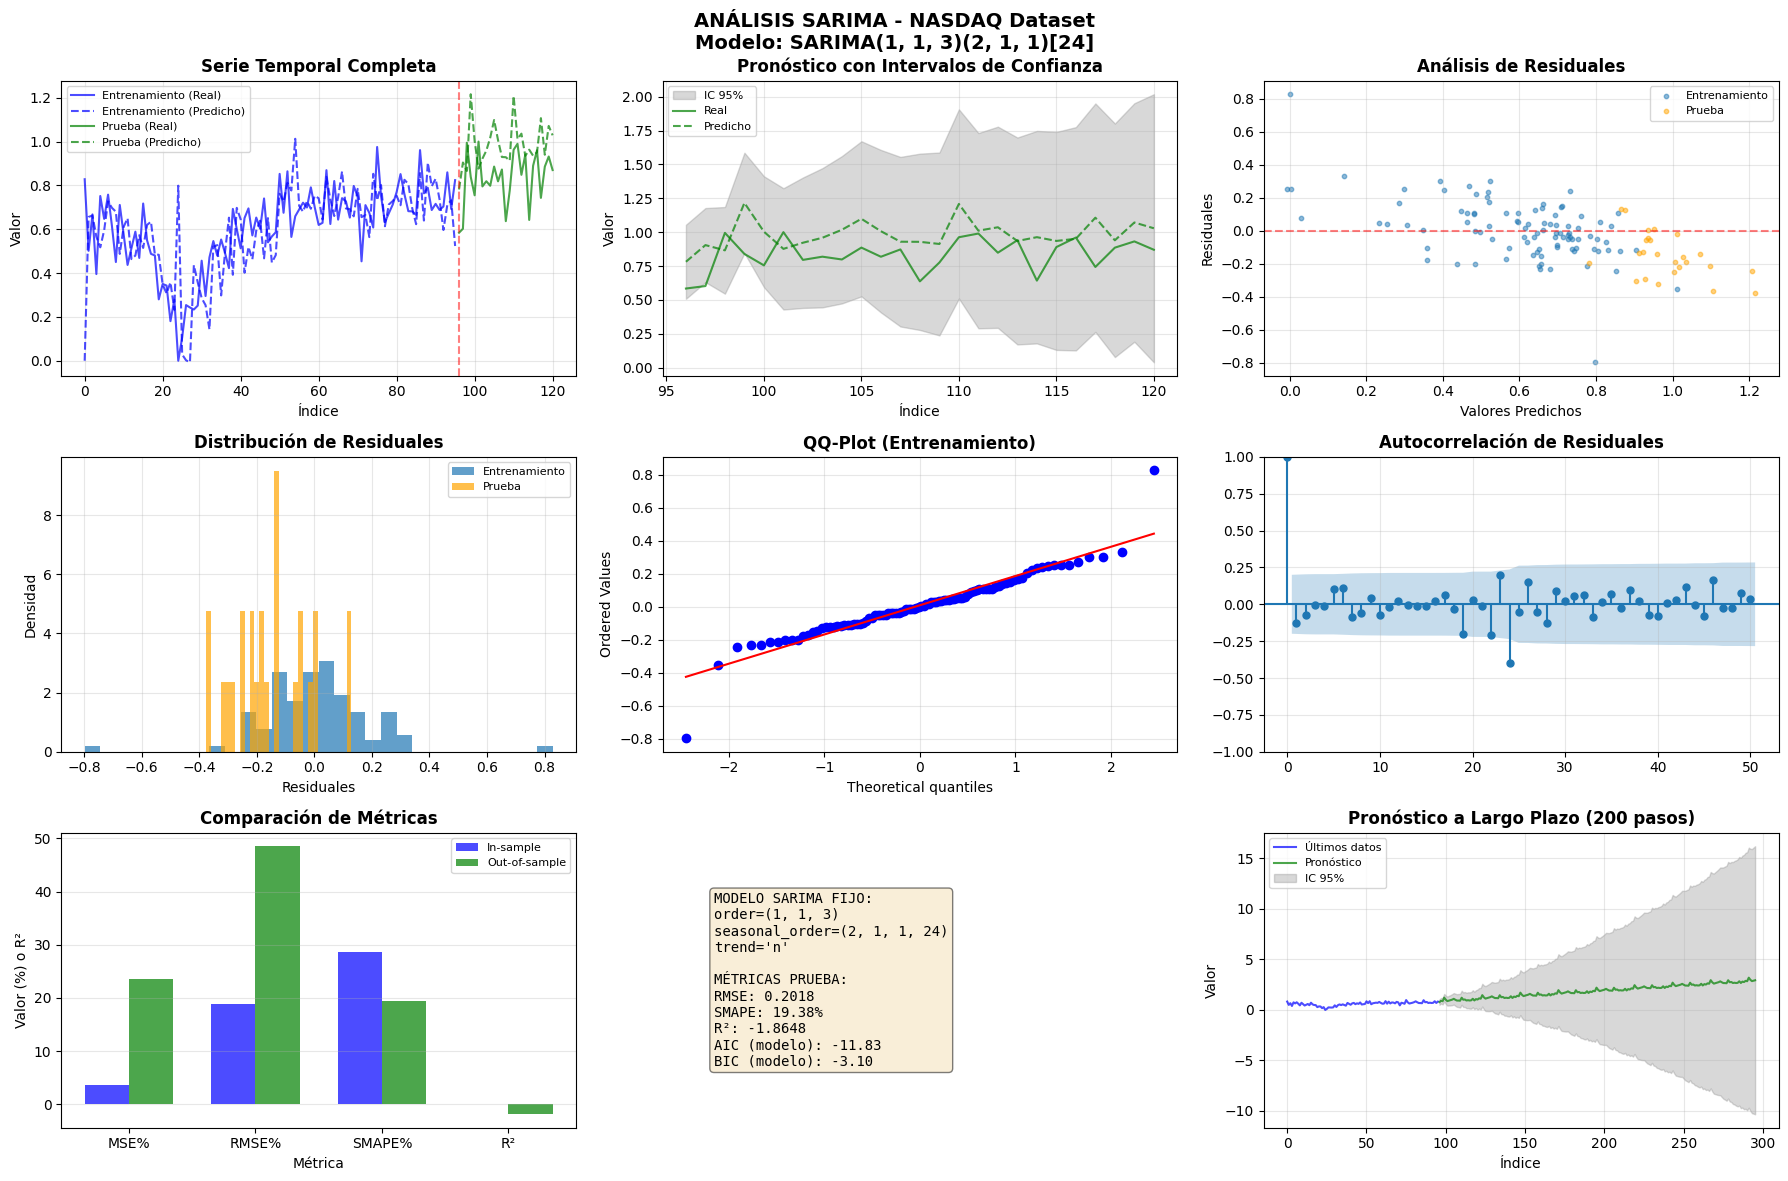

✓ Visualizaciones guardadas en 'sarima_NASDAQ_analysis_fixed.png'


In [34]:
# ============================================================
# 5. VISUALIZACIONES
# ============================================================
print("\n" + "=" * 60)
print("GENERANDO VISUALIZACIONES")
print("=" * 60)

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Serie completa
ax1 = axes[0, 0]
ax1.plot(np.arange(len(y_train_actual)), y_train_actual, 'b-', alpha=0.7, label='Entrenamiento (Real)')
ax1.plot(np.arange(len(y_train_actual)), y_train_pred_vals, 'b--', alpha=0.7, label='Entrenamiento (Predicho)')
ax1.plot(np.arange(len(y_train_actual), len(y_train_actual) + len(y_test_series)),
         y_test_series.values, 'g-', alpha=0.7, label='Prueba (Real)')
ax1.plot(np.arange(len(y_train_actual), len(y_train_actual) + len(y_test_series)),
         y_test_pred.values, 'g--', alpha=0.7, label='Prueba (Predicho)')
ax1.axvline(x=len(y_train_actual), color='r', linestyle='--', alpha=0.5)
ax1.set_title('Serie Temporal Completa', fontweight='bold')
ax1.set_xlabel('Índice')
ax1.set_ylabel('Valor')
ax1.legend(loc='best', fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Intervalos de confianza (prueba)
ax2 = axes[0, 1]
test_idx = np.arange(len(y_train_actual), len(y_train_actual) + len(y_test_series))
ax2.fill_between(test_idx, y_test_low.values, y_test_up.values, alpha=0.3, color='gray', label='IC 95%')
ax2.plot(test_idx, y_test_series.values, 'g-', alpha=0.7, label='Real')
ax2.plot(test_idx, y_test_pred.values, 'g--', alpha=0.7, label='Predicho')
ax2.set_title('Pronóstico con Intervalos de Confianza', fontweight='bold')
ax2.set_xlabel('Índice')
ax2.set_ylabel('Valor')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

# 3. Residuales
ax3 = axes[0, 2]
residuales_train = y_train_actual - y_train_pred_vals
residuales_test = y_test_series.values - y_test_pred.values
ax3.scatter(y_train_pred_vals, residuales_train, alpha=0.5, s=10, label='Entrenamiento')
ax3.scatter(y_test_pred.values, residuales_test, alpha=0.5, s=10, color='orange', label='Prueba')
ax3.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax3.set_title('Análisis de Residuales', fontweight='bold')
ax3.set_xlabel('Valores Predichos')
ax3.set_ylabel('Residuales')
ax3.legend(loc='best', fontsize=8)
ax3.grid(True, alpha=0.3)
# 4. Histograma de residuales
ax4 = axes[1, 0]
ax4.hist(residuales_train, bins=30, alpha=0.7, density=True, label='Entrenamiento')
ax4.hist(residuales_test, bins=30, alpha=0.7, density=True, color='orange', label='Prueba')
ax4.set_title('Distribución de Residuales', fontweight='bold')
ax4.set_xlabel('Residuales')
ax4.set_ylabel('Densidad')
ax4.legend(loc='best', fontsize=8)
ax4.grid(True, alpha=0.3)

# 5. QQ-Plot de residuales
ax5 = axes[1, 1]
stats.probplot(residuales_train, dist="norm", plot=ax5)
ax5.set_title('QQ-Plot (Entrenamiento)', fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Autocorrelación de residuales
ax6 = axes[1, 2]
plot_acf(residuales_train, lags=50, ax=ax6, alpha=0.05)
ax6.set_title('Autocorrelación de Residuales', fontweight='bold')
ax6.grid(True, alpha=0.3)

# 7. Comparación de métricas
ax7 = axes[2, 0]
metricas_nombres = ['MSE%', 'RMSE%', 'SMAPE%', 'R²']
valores_in = [metrics_in['MSE_in_%'], metrics_in['RMSE_in_%'],
              metrics_in['SMAPE_in_%'], metrics_in['R2_in']]
valores_out = [metrics_out['MSE_out_%'], metrics_out['RMSE_out_%'],
               metrics_out['SMAPE_out_%'], metrics_out['R2_out']]

x = np.arange(len(metricas_nombres))
ancho = 0.35
ax7.bar(x - ancho/2, valores_in, ancho, label='In-sample', alpha=0.7, color='blue')
ax7.bar(x + ancho/2, valores_out, ancho, label='Out-of-sample', alpha=0.7, color='green')
ax7.set_xlabel('Métrica')
ax7.set_ylabel('Valor (%) o R²')
ax7.set_title('Comparación de Métricas', fontweight='bold')
ax7.set_xticks(x)
ax7.set_xticklabels(metricas_nombres)
ax7.legend(loc='best', fontsize=8)
ax7.grid(True, alpha=0.3, axis='y')

# 8. Parámetros del modelo
ax8 = axes[2, 1]
ax8.axis('off')
info_text = "MODELO SARIMA FIJO:\n"
info_text += f"order={ORDER}\nseasonal_order={SEASONAL_ORDER}\ntrend='{TREND}'\n"
info_text += "\nMÉTRICAS PRUEBA:\n"
info_text += f"RMSE: {metrics_out['RMSE_out']:.4f}\n"
info_text += f"SMAPE: {metrics_out['SMAPE_out_%']:.2f}%\n"
info_text += f"R²: {metrics_out['R2_out']:.4f}\n"
info_text += f"AIC (modelo): {modelo_final.aic:.2f}\n"
info_text += f"BIC (modelo): {modelo_final.bic:.2f}"
ax8.text(0.1, 0.5, info_text, fontsize=10, verticalalignment='center',
         family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 9. Pronóstico a largo plazo
ax9 = axes[2, 2]
h_largo = 200
y_largo_pred, y_largo_low, y_largo_up = forecast_sarima(modelo_final, y_train_series, h_largo)

ultimos = 100
inicio_grafico = max(len(y_train_series) - ultimos, 0)
idx_train_plot = np.arange(inicio_grafico, len(y_train_series))
idx_largo_plot = np.arange(len(y_train_series), len(y_train_series) + h_largo)

ax9.plot(idx_train_plot, y_train_series.values[inicio_grafico:], 'b-', alpha=0.7, label='Últimos datos')
ax9.plot(idx_largo_plot, y_largo_pred.values, 'g-', alpha=0.7, label='Pronóstico')
ax9.fill_between(idx_largo_plot, y_largo_low.values, y_largo_up.values,
                 alpha=0.3, color='gray', label='IC 95%')
ax9.set_title(f'Pronóstico a Largo Plazo ({h_largo} pasos)', fontweight='bold')
ax9.set_xlabel('Índice')
ax9.set_ylabel('Valor')
ax9.legend(loc='best', fontsize=8)
ax9.grid(True, alpha=0.3)

fig.suptitle(
    "ANÁLISIS SARIMA - NASDAQ Dataset\n"
    f"Modelo: SARIMA{ORDER}{SEASONAL_ORDER[:-1]}[{SEASONAL_ORDER[-1]}]",
    fontsize=14, fontweight='bold', y=0.98
)

plt.tight_layout()
plt.savefig('sarima_NASDAQ_analysis_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualizaciones guardadas en 'sarima_NASDAQ_analysis_fixed.png'")



In [ ]:
# ARNET

In [35]:
# ============================
# 6) MÉTRICAS
# ============================
def calculate_metrics(y_true, y_pred, n_params, dataset_name=""):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    min_len = min(len(y_true), len(y_pred))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]
    n = len(y_true)

    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)

    smape = 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-10)
    )

    corr = np.corrcoef(y_true, y_pred)
    r2 = float(corr[0, 1] ** 2) if np.isfinite(corr[0, 1]) else np.nan

    aic = n * np.log(mse + 1e-12) + 2 * n_params
    bic = n * np.log(mse + 1e-12) + n_params * np.log(max(n, 2))

    data_range = np.max(y_true) - np.min(y_true)
    mse_percent = 100 * mse / (data_range ** 2 + 1e-10)
    rmse_percent = 100 * rmse / (data_range + 1e-10)

    return {
        f"MSE_{dataset_name}": mse,
        f"MSE_{dataset_name}_%": mse_percent,
        f"RMSE_{dataset_name}": rmse,
        f"RMSE_{dataset_name}_%": rmse_percent,
        f"SMAPE_{dataset_name}_%": smape,
        f"R2_{dataset_name}_Pearson2": r2,
        f"AIC_{dataset_name}": aic,
        f"BIC_{dataset_name}": bic,
    }

In [36]:
# Número de parámetros real del MLP (calculado)
n_params_real = int(
    sum(np.prod(w.shape) for w in arnet.coefs_) + sum(np.prod(b.shape) for b in arnet.intercepts_)
)
print(f"Número de parámetros (calculado): {n_params_real}")

# Predicciones (en serie diferenciada-escalada)
y_train_pred = arnet.predict(X_train_delayed)
y_test_pred  = arnet.predict(X_test_delayed)

metrics_in  = calculate_metrics(y_train.ravel(), y_train_pred, n_params_real, "in")
metrics_out = calculate_metrics(y_test.ravel(),  y_test_pred,  n_params_real, "out")

# ============================
# 7) INVERTIR TRANSFORMACIONES PARA ANÁLISIS EN ESCALA ORIGINAL
# ============================
# Desescalar diferencias
y_train_true_descaled = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_train_pred_descaled = scaler.inverse_transform(y_train_pred.reshape(-1, 1)).flatten()

y_test_true_descaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_test_pred_descaled = scaler.inverse_transform(y_test_pred.reshape(-1, 1)).flatten()

# Reconstrucción a serie original (ojo: por delays se pierde max_delay al inicio)
max_delay = max(fixed_params["input_delays"])

# Para que la reconstrucción sea consistente, necesitamos el valor "inicial" del punto donde empieza el target.
# Como y[t] corresponde a X_scaled[t], y empieza en índice max_delay, el valor inicial real es:
train_first_value_recon = float(X_train_raw[max_delay])
test_first_value_recon  = float(X_test_raw[max_delay])

train_series_true = reconstruct_series_from_diffs(y_train_true_descaled, train_first_value_recon)
train_series_pred = reconstruct_series_from_diffs(y_train_pred_descaled, train_first_value_recon)

test_series_true = reconstruct_series_from_diffs(y_test_true_descaled, test_first_value_recon)
test_series_pred = reconstruct_series_from_diffs(y_test_pred_descaled, test_first_value_recon)


Número de parámetros (calculado): 711


In [37]:
# ============================
# 8) GRÁFICAS - ESCALA ORIGINAL
# ============================
# ----------------------------
# Construir ejes de índice
# ----------------------------
n_tr = len(train_series_true)
n_te = len(test_series_true)

idx_tr = np.arange(0, n_tr)
idx_te = np.arange(n_tr, n_tr + n_te)

# Para serie completa (concatenada)
series_true_full = np.concatenate([train_series_true, test_series_true])
series_pred_full = np.concatenate([train_series_pred, test_series_pred])
idx_full = np.arange(0, len(series_true_full))

# ----------------------------
# Residuales EN ESCALA ORIGINAL
# ----------------------------
res_train_orig = train_series_true - train_series_pred
res_test_orig  = test_series_true  - test_series_pred

# Métricas a mostrar (ya calculadas)
rmse_test  = metrics_out["RMSE_out"]
smape_test = metrics_out["SMAPE_out_%"]
r2_test    = metrics_out["R2_out_Pearson2"]

# ----------------------------
# Figura tipo dashboard (3x3)
# ----------------------------
fig = plt.figure(figsize=(20, 14))
plt.suptitle("ANÁLISIS MLP - NASDAQ Dataset", fontsize=18, fontweight="bold")


Text(0.5, 0.98, 'ANÁLISIS MLP - NASDAQ Dataset')

<Figure size 2000x1400 with 0 Axes>

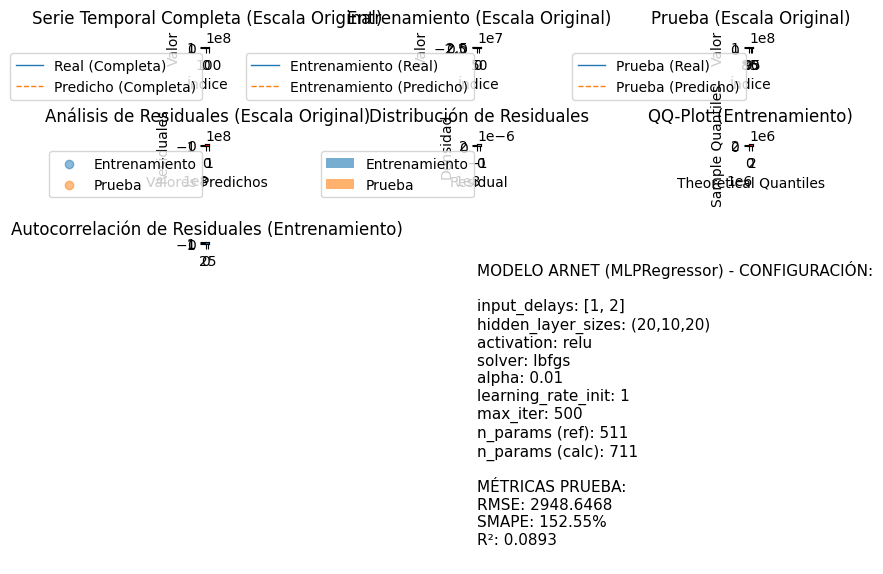

In [39]:
# ------------------------------------------------
# (1) Serie completa (original) + split marker
# ------------------------------------------------
ax1 = plt.subplot(3, 3, 1)
ax1.plot(idx_full, series_true_full, label="Real (Completa)", linewidth=1)
ax1.plot(idx_full, series_pred_full, label="Predicho (Completa)", linestyle="--", linewidth=1)
ax1.axvline(n_tr - 1, linestyle="--", color="red", linewidth=1)  # frontera train/test
ax1.set_title("Serie Temporal Completa (Escala Original)")
ax1.set_xlabel("Índice")
ax1.set_ylabel("Valor")
ax1.legend()
ax1.grid(True)

# ------------------------------------------------
# (2) Entrenamiento separado
# ------------------------------------------------
ax2 = plt.subplot(3, 3, 2)
ax2.plot(idx_tr, train_series_true, label="Entrenamiento (Real)", linewidth=1)
ax2.plot(idx_tr, train_series_pred, label="Entrenamiento (Predicho)", linestyle="--", linewidth=1)
ax2.set_title("Entrenamiento (Escala Original)")
ax2.set_xlabel("Índice")
ax2.set_ylabel("Valor")
ax2.legend()
ax2.grid(True)

# ------------------------------------------------
# (3) Prueba separado
# ------------------------------------------------
ax3 = plt.subplot(3, 3, 3)
ax3.plot(idx_te, test_series_true, label="Prueba (Real)", linewidth=1)
ax3.plot(idx_te, test_series_pred, label="Prueba (Predicho)", linestyle="--", linewidth=1)
ax3.set_title("Prueba (Escala Original)")
ax3.set_xlabel("Índice")
ax3.set_ylabel("Valor")
ax3.legend()
ax3.grid(True)

# ------------------------------------------------
# (4) Análisis de residuales (Predicho vs Residual) - ORIGINAL
# ------------------------------------------------
ax4 = plt.subplot(3, 3, 4)
ax4.scatter(train_series_pred, res_train_orig, alpha=0.5, label="Entrenamiento")
ax4.scatter(test_series_pred,  res_test_orig,  alpha=0.5, label="Prueba")
ax4.axhline(0, linestyle="--", color="red")
ax4.set_title("Análisis de Residuales (Escala Original)")
ax4.set_xlabel("Valores Predichos")
ax4.set_ylabel("Residuales")
ax4.legend()
ax4.grid(True)

# ------------------------------------------------
# (5) Distribución de residuales - ORIGINAL
# ------------------------------------------------
ax5 = plt.subplot(3, 3, 5)
ax5.hist(res_train_orig, bins=30, alpha=0.6, label="Entrenamiento", density=True)
ax5.hist(res_test_orig,  bins=30, alpha=0.6, label="Prueba", density=True)
ax5.set_title("Distribución de Residuales")
ax5.set_xlabel("Residual")
ax5.set_ylabel("Densidad")
ax5.legend()
ax5.grid(True)

# ------------------------------------------------
# (6) QQ-Plot (Entrenamiento) - ORIGINAL
# ------------------------------------------------
ax6 = plt.subplot(3, 3, 6)
sm.qqplot(res_train_orig, line="45", ax=ax6)
ax6.set_title("QQ-Plot (Entrenamiento)")

# ------------------------------------------------
# (7) ACF de residuales (Entrenamiento) - ORIGINAL
# ------------------------------------------------
ax7 = plt.subplot(3, 3, 7)
plot_acf(res_train_orig, ax=ax7, lags=40)
ax7.set_title("Autocorrelación de Residuales (Entrenamiento)")

# ------------------------------------------------
# (8) Cuadro de métricas / configuración
# ------------------------------------------------
ax8 = plt.subplot(3, 3, 8)
ax8.axis("off")
text_metrics = f"""
MODELO ARNET (MLPRegressor) - CONFIGURACIÓN:

input_delays: [1, 2]
hidden_layer_sizes: (20,10,20)
activation: relu
solver: lbfgs
alpha: 0.01
learning_rate_init: 1
max_iter: 500
n_params (ref): 511
n_params (calc): {n_params_real}

MÉTRICAS PRUEBA:
RMSE: {rmse_test:.4f}
SMAPE: {smape_test:.2f}%
R²: {r2_test:.4f}
"""
ax8.text(0.02, 0.98, text_metrics, fontsize=11, va="top")


plt.tight_layout()
plt.show()



##### Comparando Resultados   _________________________________________________________________________________________________________________________________________________

In [ ]:
# ============================================================
# 6. GUARDAR RESULTADOS
# ============================================================
print("\n" + "=" * 60)
print("GUARDANDO RESULTADOS")
print("=" * 60)

joblib.dump(modelo_final, 'sarima_fixed_model.pkl')
print("✓ Modelo guardado en 'sarima_fixed_model.pkl'")

with open('sarima_fixed_metrics.txt', 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("RESULTADOS SARIMA\n")
    f.write("=" * 60 + "\n\n")

    f.write("MODELO UTILIZADO:\n")
    f.write("-" * 40 + "\n")
    f.write(f"order={ORDER}\n")
    f.write(f"seasonal_order={SEASONAL_ORDER}\n")
    f.write(f"trend='{TREND}'\n")
    f.write(f"AIC (modelo): {modelo_final.aic:.6f}\n")
    f.write(f"BIC (modelo): {modelo_final.bic:.6f}\n\n")

    f.write("MÉTRICAS IN-SAMPLE (Entrenamiento):\n")
    f.write("-" * 40 + "\n")
    for key, value in metrics_in.items():
        if 'n_' not in key:
            f.write(f"{key}: {value:.6f}\n")
    f.write("\n")

    f.write("MÉTRICAS OUT-OF-SAMPLE (Prueba):\n")
    f.write("-" * 40 + "\n")
    for key, value in metrics_out.items():
        if 'n_' not in key:
            f.write(f"{key}: {value:.6f}\n")
    f.write("\n")

print("✓ Métricas guardadas en 'sarima_fixed_metrics.txt'")

print("\n" + "=" * 60)
print("¡PROCESO COMPLETADO EXITOSAMENTE!")
print("=" * 60)

In [ ]:
# GUARDAR RESULTADO ARNET

# ============================
# 10) GUARDAR MODELO Y RESULTADOS
# ============================
joblib.dump(arnet, "arnet_model_fixed.pkl")
joblib.dump(scaler, "arnet_scaler_fixed.pkl")
print("\nModelo guardado: arnet_model_fixed.pkl")
print("Scaler guardado: arnet_scaler_fixed.pkl")

with open("arnet_model_metrics_fixed.txt", "w", encoding="utf-8") as f:
    f.write("=== MODELO ARNET (MLPRegressor) ===\n")
    for k, v in fixed_params.items():
        f.write(f"{k}: {v}\n")
    f.write(f"n_params_calculado: {n_params_real}\n")
    f.write(f"training_time_s: {train_time:.4f}\n\n")

    f.write("=== MÉTRICAS IN-SAMPLE (ENTRENAMIENTO) ===\n")
    for k, v in metrics_in.items():
        f.write(f"{k}: {v}\n")

    f.write("\n=== MÉTRICAS OUT-OF-SAMPLE (PRUEBA) ===\n")
    for k, v in metrics_out.items():
        f.write(f"{k}: {v}\n")

print("Métricas guardadas: arnet_model_metrics_fixed.txt")

print("\nListo.")

### Segunda Parte

Al dataset seleccionado en la tarea de clasificación:

1. Eliminar la columna de las etiquetas de clases.

2. Aplicar Hierarchical Clustering y K-MEANS.

3. Mostrar métricas para evaluar la calidad.

4. Graficar el dataset original, los cluster dados por los algoritmos y comparar

##### Eliminamos Etiquetas ____________________________________________________________________________________________________________________________________________

In [40]:
Datos_IBM = pd.read_csv('IBM.csv')
Datos_IBM.head()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
1,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
2,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
3,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
4,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2


In [41]:
# COLUMNA OBJETIVO : Attrition
Datos_IBM_SC = Datos_IBM.drop(columns=["Attrition"])

##### Aplicando Hierarchical Clustering y K-Means ______________________________________________________________________________________________________________________

In [45]:
Datos_IBM_SC

,Age,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
1,49,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
2,37,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
3,33,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
4,27,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,Research & Development,23,2,Medical,3,4,Married,2571,4,3,5
1466,39,Research & Development,6,1,Medical,4,1,Married,9991,4,3,7
1467,27,Research & Development,4,3,Life Sciences,2,2,Married,6142,1,3,6
1468,49,Sales,2,3,Medical,4,2,Married,5390,2,2,9


In [ ]:
# TRANSFORMAMOS LOS DATOS CATEGORICOS









In [44]:

from utils import *
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import linkage

# SEMILLA 
SEMILLA = 2026

X = Datos_IBM_SC.values
feature_names = Datos_IBM_SC.columns

# ESCALAMOS LOS DATOS
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# VISUALIZAMOS EN 2D
idx_a, idx_b = 0, 1
X2 = Xs[:, [idx_a, idx_b]]
xlab = f"{feature_names[idx_a]} (scaled)"
ylab = f"{feature_names[idx_b]} (scaled)"

ValueError: could not convert string to float: 'Sales'

In [ ]:
# -------------------------
# A) Clustering Jerárquico
# -------------------------
y_true = iris.target
class_names = iris.target_names

Z = linkage(Xs, method="ward")
hier = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_h = hier.fit_predict(Xs)

In [ ]:
# -----------
# B) K-Means
# -----------
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=SEMILLA)
labels_k = kmeans.fit_predict(Xs)

##### Metricas _____________________________________________________________________________________________________________________________________________________________

In [ ]:
evaluate_clustering(Xs, labels_k, name="K-Means (k=3, k-means++, n_init=10)")
evaluate_clustering(Xs, labels_h, name="Hierarchical (Agglomerative, ward, k=3)")


##### Comparaciones ______________________________________________________________________________________________________________________________________________________

In [ ]:
# -------------
# C) Visualización comparativa en un solo lienzo
# -------------
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# dendrograma
from scipy.cluster.hierarchy import dendrogram

dendrogram(Z, truncate_mode="level", p=5, ax=axs[0, 0])
axs[0, 0].set_title("Dendrograma (ward)")
axs[0, 0].set_xlabel("Índices / clusters combinados")
axs[0, 0].set_ylabel("Distancia")

cmap = plt.cm.rainbow
norm = plt.Normalize(vmin=0, vmax=2)
axs[0, 1].scatter(X2[:, 0], X2[:, 1], c=labels_h, s=35, cmap=cmap, norm=norm)
axs[0, 1].set_title("Hierarchical k=3")
axs[0, 1].set_xlabel(xlab)
axs[0, 1].set_ylabel(ylab)

# k-means (2D) con mismo esquema de colores
axs[1, 0].scatter(X2[:, 0], X2[:, 1], c=labels_k, s=35, cmap=cmap, norm=norm)
axs[1, 0].set_title("K-Means k=3")
axs[1, 0].set_xlabel(xlab)
axs[1, 0].set_ylabel(ylab)

# clases reales (2D) igual
axs[1, 1].scatter(X2[:, 0], X2[:, 1], c=y_true, s=35, cmap=cmap, norm=norm)
axs[1, 1].set_title("Clases reales")
axs[1, 1].set_xlabel(xlab)
axs[1, 1].set_ylabel(ylab)

if class_names is not None:
    handles = []
    for lbl in np.unique(y_true):
        handles.append(plt.Line2D([0], [0], marker="o", color="w",
                                  markerfacecolor=plt.cm.rainbow(lbl / len(class_names)),
                                  markersize=6))
    axs[1, 1].legend(handles, class_names, title="Clases", loc="best")

plt.tight_layout()
plt.show()